# 0. 세팅하기

## 0. 설치하기

In [1]:
!pip install duckdb

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.8 MB/s eta 0:00:0000:0100:01


In [16]:
!pip install python-dotenv

Defaulting to user installation because normal site-packages is not writeable


## 1. 세팅하기

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [2]:
import duckdb as dd
import dotenv
import os
import pandas as pd

In [3]:
# 한글 폰트 지정
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'  # 경로 확인 필요
fontprop = fm.FontProperties(fname=font_path)

plt.rc('font', family=fontprop.get_name())

In [4]:
# 컬럼 모두 출력
pd.set_option('display.max_columns', None)

In [5]:
# .env 파일 경로 찾기

env_path = dotenv.find_dotenv()

In [6]:
# .env 파일 불러오기  (내용이 있으면 -> True, 없으면 -> False)

dotenv.load_dotenv(
    dotenv_path=env_path,
    override=True
)

True

In [9]:
mem_con = dd.connect("mydb_copy.duckdb")

In [10]:
HMAC_ID = os.getenv("HMAC_ID")
HMAC_PW = os.getenv("HMAC_PW")

secret_gcs = f"""
CREATE SECRET (
    TYPE GCS,
    KEY_ID '{HMAC_ID}',
    SECRET '{HMAC_PW}'
);
"""

mem_con.execute(secret_gcs)

In [11]:
mem_con.execute("FROM duckdb_secrets()").df()

,name,type,provider,persistent,storage,scope,secret_string
0,__default_gcs,gcs,config,False,memory,"[gcs://, gs://]",name=__default_gcs;type=gcs;provider=config;se...


## 2. 파일 불러오기

### 1) 기존데이블

In [128]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_timelinereport.parquet')
"""

timelinereport_df = mem_con.execute(_query).df()

In [122]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_paymenthistory.parquet')
"""

paymenthistory_df = mem_con.execute(_query).df()

In [123]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_failpaymenthistory.parquet')
"""

failpaymenthistory_df = mem_con.execute(_query).df()

In [119]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/event_receipts.parquet')
"""

event_receipts_df = mem_con.execute(_query).df()

In [21]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_userwithdraw.parquet')
"""

userwithdraw_df = mem_con.execute(_query).df()

In [101]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_userquestionrecord.parquet')
"""

userquestionrecord_df = mem_con.execute(_query).df()

In [102]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_attendance.parquet')
"""

attendance_df = mem_con.execute(_query).df()

In [103]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_pointhistory.parquet')
"""

pointhistory_df = mem_con.execute(_query).df()

In [104]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_questionpiece.parquet')
"""

polls_questionpiece_df = mem_con.execute(_query).df()

In [105]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_questionset.parquet')
"""

polls_questionset_df = mem_con.execute(_query).df()

In [106]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_question.parquet')
"""

polls_question_df = mem_con.execute(_query).df()

### 2) 병합테이블

In [17]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_paymenthistory.parquet')
"""

paymenthistory_df = mem_con.execute(_query).df()

In [18]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/question_df.parquet')
"""

question_df = mem_con.execute(_query).df()

In [81]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/vote_point_df.parquet')
"""

vote_point_df = mem_con.execute(_query).df()

In [20]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/event_info_df.parquet')
"""

event_info_df = mem_con.execute(_query).df()

In [28]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/user_df.parquet')
"""

user_df = mem_con.execute(_query).df()

### 3) duckdb에 저장

In [ ]:
# mem_con.execute("""
#                 CREATE TABLE user_df AS
#                 SELECT * FROM user_df
#                 """)

In [ ]:
# mem_con.execute("""
#                 CREATE TABLE vote_point_df AS
#                 SELECT * FROM vote_point_df
#                 """)

### 4) duckdb 확인

In [85]:
tables = mem_con.execute("SHOW TABLES").fetchall()
print(tables)

[('event_info_df',), ('paymenthistory_df',), ('question_df',), ('user_df',), ('user_df_ver2',), ('vote_point_df',)]


# 2. 피쳐엔지니어링

### 2) 질문테이블 : 질문piece, 질문set, 질문 테이블 병합

questionset 1정규화

In [132]:
polls_questionset_df.head()

,id,question_piece_id_list,opening_time,status,created_at,user_id
0,99817,"[998458, 998459, 998460, 998461, 998462, 99846...",2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
1,99830,"[998588, 998589, 998590, 998591, 998592, 99859...",2023-04-28 12:28:07,F,2023-04-28 12:28:07,849438
2,99840,"[998689, 998691, 998693, 998695, 998697, 99869...",2023-04-28 12:28:38,F,2023-04-28 12:28:38,847375
3,99841,"[998688, 998690, 998692, 998694, 998696, 99869...",2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446
4,99848,"[998768, 998769, 998770, 998771, 998772, 99877...",2023-04-28 12:28:57,F,2023-04-28 12:28:57,849477


In [133]:
print("shape : ", polls_questionpiece_df.shape)
print("id 갯수 : ", polls_questionpiece_df['id'].nunique())

shape :  (1265476, 5)


id 갯수 :  1265476


In [134]:
# 정규화 대상 DataFrame
df = polls_questionset_df.copy()

# 리스트 컬럼 정규화 (explode 사용)
df['question_piece_id_list'] = df['question_piece_id_list'].apply(eval)  # 문자열로 저장된 리스트를 진짜 리스트로 변환
normalized_df = df.explode('question_piece_id_list')[['id', 'question_piece_id_list']]

# 열 이름 바꾸기 (선택사항)
normalized_df = normalized_df.rename(columns={'question_piece_id_list': 'question_piece_id'})

# 결과 확인
normalized_df.head()

,id,question_piece_id
0,99817,998458
0,99817,998459
0,99817,998460
0,99817,998461
0,99817,998462


In [135]:
merged_df = normalized_df.merge(
    df[['id', 'opening_time', 'status', 'created_at', 'user_id']],
    how='left',
    on='id'
)

In [136]:
# 정규화 완료 테이블
merged_df.head()

,id,question_piece_id,opening_time,status,created_at,user_id
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436


In [137]:
# question_piece_id 중복값 확인
merged_df['question_piece_id'].duplicated().sum()

0

In [138]:
merged_df['question_piece_id'].nunique()

1583840

questionpiece 테이블 합치기

In [139]:
polls_questionpiece_df.head()

,id,is_voted,created_at,question_id,is_skipped
0,998458,1,2023-04-28 12:27:22,252,0
1,998459,1,2023-04-28 12:27:22,244,0
2,998460,1,2023-04-28 12:27:22,183,0
3,998461,1,2023-04-28 12:27:22,101,0
4,998462,1,2023-04-28 12:27:22,209,0


In [140]:
merged_df.head()

,id,question_piece_id,opening_time,status,created_at,user_id
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436


In [141]:
question_df = merged_df.merge(
    polls_questionpiece_df, 
    how='left', 
    left_on='question_piece_id', 
    right_on='id',
    suffixes=('_set','_piece'))

In [142]:
question_df.head(20)

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,id_piece,is_voted,created_at_piece,question_id,is_skipped
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998458.0,1.0,2023-04-28 12:27:22,252.0,0.0
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998459.0,1.0,2023-04-28 12:27:22,244.0,0.0
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998460.0,1.0,2023-04-28 12:27:22,183.0,0.0
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998461.0,1.0,2023-04-28 12:27:22,101.0,0.0
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998462.0,1.0,2023-04-28 12:27:22,209.0,0.0
5,99817,998463,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998463.0,1.0,2023-04-28 12:27:22,239.0,0.0
6,99817,998464,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998464.0,1.0,2023-04-28 12:27:22,146.0,0.0
7,99817,998465,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998465.0,1.0,2023-04-28 12:27:22,297.0,0.0
8,99817,998466,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998466.0,1.0,2023-04-28 12:27:22,294.0,0.0
9,99817,998467,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998467.0,1.0,2023-04-28 12:27:22,201.0,0.0


In [143]:
question_df.isna().sum()

id_set                    0
question_piece_id         0
opening_time              0
status                    0
created_at_set            0
user_id                   0
id_piece             318364
is_voted             318364
created_at_piece     318364
question_id          318364
is_skipped           318364
dtype: int64

In [144]:
nan_rows = question_df[question_df.isna().any(axis=1)]
nan_rows

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,id_piece,is_voted,created_at_piece,question_id,is_skipped
18,99830,998596,2023-04-28 12:28:07,F,2023-04-28 12:28:07,849438,NaN,NaN,NaT,NaN,NaN
30,99841,998688,2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446,NaN,NaN,NaT,NaN,NaN
31,99841,998690,2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446,NaN,NaN,NaT,NaN,NaN
32,99841,998692,2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446,NaN,NaN,NaT,NaN,NaN
35,99841,998698,2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446,NaN,NaN,NaT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1583694,20835070,208351465,2024-03-19 12:53:58,F,2024-03-19 12:53:58,1583358,NaN,NaN,NaT,NaN,NaN
1583695,20835070,208351466,2024-03-19 12:53:58,F,2024-03-19 12:53:58,1583358,NaN,NaN,NaT,NaN,NaN
1583696,20835070,208351467,2024-03-19 12:53:58,F,2024-03-19 12:53:58,1583358,NaN,NaN,NaT,NaN,NaN
1583698,20835070,208351469,2024-03-19 12:53:58,F,2024-03-19 12:53:58,1583358,NaN,NaN,NaT,NaN,NaN


In [145]:
nan_rows['status'].value_counts()

status
F    318351
O        11
C         2
Name: count, dtype: int64

polls_question_df랑 merge

In [146]:
polls_question_df.head()

,id,question_text,created_at
0,99,가장 신비한 매력이 있는 사람은?,2023-03-31 15:22:53
1,100,"""이 사람으로 한 번 살아보고 싶다"" 하는 사람은?",2023-03-31 15:22:53
2,101,미래의 틱톡커는?,2023-03-31 15:22:54
3,102,여기서 제일 특이한 친구는?,2023-03-31 15:22:54
4,103,가장 지켜주고 싶은 사람은?,2023-03-31 15:22:55


In [147]:
question_df2 = question_df.merge(
  polls_question_df,
  how='left',
  left_on='question_id',
  right_on='id'
)

In [148]:
question_df2.head()

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,id_piece,is_voted,created_at_piece,question_id,is_skipped,id,question_text,created_at
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998458.0,1.0,2023-04-28 12:27:22,252.0,0.0,252.0,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998459.0,1.0,2023-04-28 12:27:22,244.0,0.0,244.0,대학교에서 학생회장할 것 같은 사람은?,2023-04-01 11:09:26
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998460.0,1.0,2023-04-28 12:27:22,183.0,0.0,183.0,나의 자존감을 가장 많이 높여줬던 사람은?,2023-04-01 11:09:14
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998461.0,1.0,2023-04-28 12:27:22,101.0,0.0,101.0,미래의 틱톡커는?,2023-03-31 15:22:54
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998462.0,1.0,2023-04-28 12:27:22,209.0,0.0,209.0,항상 좋은 냄새가 나는 사람은?,2023-04-01 11:09:20


null 제거

In [149]:
question_df2.isna().sum()

id_set                    0
question_piece_id         0
opening_time              0
status                    0
created_at_set            0
user_id                   0
id_piece             318364
is_voted             318364
created_at_piece     318364
question_id          318364
is_skipped           318364
id                   318364
question_text        318364
created_at           318364
dtype: int64

In [150]:
question_df_notnull = question_df2.dropna()
question_df_notnull

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,id_piece,is_voted,created_at_piece,question_id,is_skipped,id,question_text,created_at
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998458.0,1.0,2023-04-28 12:27:22,252.0,0.0,252.0,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998459.0,1.0,2023-04-28 12:27:22,244.0,0.0,244.0,대학교에서 학생회장할 것 같은 사람은?,2023-04-01 11:09:26
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998460.0,1.0,2023-04-28 12:27:22,183.0,0.0,183.0,나의 자존감을 가장 많이 높여줬던 사람은?,2023-04-01 11:09:14
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998461.0,1.0,2023-04-28 12:27:22,101.0,0.0,101.0,미래의 틱톡커는?,2023-03-31 15:22:54
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998462.0,1.0,2023-04-28 12:27:22,209.0,0.0,209.0,항상 좋은 냄새가 나는 사람은?,2023-04-01 11:09:20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1583835,20838446,208385226,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,208385226.0,0.0,2024-05-07 11:32:30,960.0,0.0,960.0,가장 인싸일 것 같은 친구는?,2023-05-15 14:00:19
1583836,20838446,208385227,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,208385227.0,0.0,2024-05-07 11:32:30,1402.0,0.0,1402.0,가장 리더쉽 있을 것 같은 사람,2023-05-15 14:03:19
1583837,20838446,208385228,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,208385228.0,0.0,2024-05-07 11:32:30,1676.0,0.0,1676.0,화장 전후 가장 비슷할 것 같은 사람은?,2023-06-02 08:06:24
1583838,20838446,208385229,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,208385229.0,0.0,2024-05-07 11:32:30,3115.0,0.0,3115.0,가장 박새로이컷이 잘 어울릴 것 같은 사람,2023-06-02 08:07:08


In [151]:
question_df_notnull.shape

(1265476, 14)

columns 정리

In [152]:
question_df_notnull.columns

Index(['id_set', 'question_piece_id', 'opening_time', 'status',
       'created_at_set', 'user_id', 'id_piece', 'is_voted', 'created_at_piece',
       'question_id', 'is_skipped', 'id', 'question_text', 'created_at'],
      dtype='object')

In [153]:
final_question_df = question_df_notnull[['id_set', 'question_piece_id', 'opening_time', 'status',
                                          'created_at_set', 'user_id', 'is_voted', 'is_skipped', 'created_at_piece',
                                          'question_id',  'question_text']]

In [154]:
final_question_df

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,is_voted,is_skipped,created_at_piece,question_id,question_text
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,252.0,손이 가장 이쁘게 생겼을거 같은 사람은?
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,244.0,대학교에서 학생회장할 것 같은 사람은?
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,183.0,나의 자존감을 가장 많이 높여줬던 사람은?
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,101.0,미래의 틱톡커는?
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,209.0,항상 좋은 냄새가 나는 사람은?
...,...,...,...,...,...,...,...,...,...,...,...
1583835,20838446,208385226,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,960.0,가장 인싸일 것 같은 친구는?
1583836,20838446,208385227,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,1402.0,가장 리더쉽 있을 것 같은 사람
1583837,20838446,208385228,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,1676.0,화장 전후 가장 비슷할 것 같은 사람은?
1583838,20838446,208385229,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,3115.0,가장 박새로이컷이 잘 어울릴 것 같은 사람


추출하기

In [155]:
# mem_con.execute("""
#                COPY final_question_df TO 'gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/question_df.parquet' (FORMAT PARQUET);
#                """)

### 3) 투표, 포인트사용이력 outer join

In [96]:
userquestionrecord_df.head(1)

,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times
0,771777,C,2023-04-28 12:27:49,849469,252,849436,998458,0,N,2023-04-28 12:27:49,0,0


In [97]:
pointhistory_df.head(1)

,id,delta_point,created_at,user_id,user_question_record_id
0,790629,9,2023-04-28 12:27:49,849436,771777.0


In [99]:
print(userquestionrecord_df.shape)
print(pointhistory_df.shape)

(1217558, 12)
(2338918, 5)


In [102]:
vote_point_merge = userquestionrecord_df.merge(
    pointhistory_df[['delta_point', 'created_at', 'user_id', 'user_question_record_id']],
    how="outer",
    left_on="id",
    right_on="user_question_record_id"
)

In [103]:
vote_point_merge.head()

,id,status,created_at_x,chosen_user_id,question_id,user_id_x,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,delta_point,created_at_y,user_id_y,user_question_record_id
0,771777.0,C,2023-04-28 12:27:49,849469.0,252.0,849436.0,998458.0,0.0,N,2023-04-28 12:27:49,0.0,0.0,9.0,2023-04-28 12:27:49,849436.0,771777.0
1,771800.0,C,2023-04-28 12:28:02,849446.0,244.0,849436.0,998459.0,0.0,N,2023-04-28 12:28:02,0.0,0.0,9.0,2023-04-28 12:28:02,849436.0,771800.0
2,771812.0,C,2023-04-28 12:28:09,849454.0,183.0,849436.0,998460.0,1.0,N,2023-04-28 12:28:09,0.0,0.0,5.0,2023-04-28 12:28:09,849436.0,771812.0
3,771828.0,C,2023-04-28 12:28:16,847375.0,101.0,849436.0,998461.0,0.0,N,2023-04-28 12:28:16,0.0,0.0,13.0,2023-04-28 12:28:16,849436.0,771828.0
4,771851.0,C,2023-04-28 12:28:26,849477.0,209.0,849436.0,998462.0,1.0,N,2023-04-28 12:28:26,0.0,0.0,5.0,2023-04-28 12:28:26,849436.0,771851.0


In [105]:
merge_df = vote_point_merge[['created_at_x', 'id',	'status',		'chosen_user_id',	'question_id',	'user_id_x',
                  'question_piece_id',	'has_read',	'answer_status',	'answer_updated_at',	'report_count',
                  'opened_times',	'delta_point',	'created_at_y',	'user_id_y']]

merge_df.head()

,created_at_x,id,status,chosen_user_id,question_id,user_id_x,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,delta_point,created_at_y,user_id_y
0,2023-04-28 12:27:49,771777.0,C,849469.0,252.0,849436.0,998458.0,0.0,N,2023-04-28 12:27:49,0.0,0.0,9.0,2023-04-28 12:27:49,849436.0
1,2023-04-28 12:28:02,771800.0,C,849446.0,244.0,849436.0,998459.0,0.0,N,2023-04-28 12:28:02,0.0,0.0,9.0,2023-04-28 12:28:02,849436.0
2,2023-04-28 12:28:09,771812.0,C,849454.0,183.0,849436.0,998460.0,1.0,N,2023-04-28 12:28:09,0.0,0.0,5.0,2023-04-28 12:28:09,849436.0
3,2023-04-28 12:28:16,771828.0,C,847375.0,101.0,849436.0,998461.0,0.0,N,2023-04-28 12:28:16,0.0,0.0,13.0,2023-04-28 12:28:16,849436.0
4,2023-04-28 12:28:26,771851.0,C,849477.0,209.0,849436.0,998462.0,1.0,N,2023-04-28 12:28:26,0.0,0.0,5.0,2023-04-28 12:28:26,849436.0


In [108]:
# 조건 정의
conditions = [
    merge_df["user_id_y"] == merge_df["user_id_x"],
    merge_df["user_id_y"] == merge_df["chosen_user_id"]
]

# 각 조건에 해당하는 값
choices = ["chooser", "chosen"]

# 새 컬럼 추가
merge_df["point_user"] = np.select(conditions, choices, default=None)

In [109]:
merge_df[merge_df['point_user'] == 'chosen'].head()

,created_at_x,id,status,chosen_user_id,question_id,user_id_x,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,delta_point,created_at_y,user_id_y,user_role,point_user
11,2023-04-28 12:29:13,771940.0,I,849634.0,297.0,849436.0,998465.0,1.0,N,2023-04-28 12:29:13,0.0,1.0,-300.0,2023-05-07 04:40:33,849634.0,chosen,chosen
36,2023-04-28 12:30:48,772123.0,I,849489.0,209.0,849452.0,999059.0,0.0,N,2023-04-28 12:30:48,0.0,1.0,-300.0,2023-04-28 17:28:06,849489.0,chosen,chosen
38,2023-04-28 12:30:49,772126.0,I,849488.0,257.0,849438.0,998594.0,1.0,N,2023-04-28 12:30:49,0.0,2.0,-300.0,2023-05-07 17:15:28,849488.0,chosen,chosen
39,2023-04-28 12:30:49,772126.0,I,849488.0,257.0,849438.0,998594.0,1.0,N,2023-04-28 12:30:49,0.0,2.0,-500.0,2023-06-04 06:34:27,849488.0,chosen,chosen
100,2023-04-28 12:33:33,772488.0,I,849446.0,245.0,849445.0,999492.0,0.0,N,2023-04-28 12:33:33,0.0,1.0,-300.0,2023-05-01 09:00:56,849446.0,chosen,chosen


In [112]:
merge_df = merge_df.drop(columns=['user_id_y'])

In [113]:
merge_df.head()

,created_at_x,id,status,chosen_user_id,question_id,user_id_x,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,delta_point,created_at_y,point_user
0,2023-04-28 12:27:49,771777.0,C,849469.0,252.0,849436.0,998458.0,0.0,N,2023-04-28 12:27:49,0.0,0.0,9.0,2023-04-28 12:27:49,chooser
1,2023-04-28 12:28:02,771800.0,C,849446.0,244.0,849436.0,998459.0,0.0,N,2023-04-28 12:28:02,0.0,0.0,9.0,2023-04-28 12:28:02,chooser
2,2023-04-28 12:28:09,771812.0,C,849454.0,183.0,849436.0,998460.0,1.0,N,2023-04-28 12:28:09,0.0,0.0,5.0,2023-04-28 12:28:09,chooser
3,2023-04-28 12:28:16,771828.0,C,847375.0,101.0,849436.0,998461.0,0.0,N,2023-04-28 12:28:16,0.0,0.0,13.0,2023-04-28 12:28:16,chooser
4,2023-04-28 12:28:26,771851.0,C,849477.0,209.0,849436.0,998462.0,1.0,N,2023-04-28 12:28:26,0.0,0.0,5.0,2023-04-28 12:28:26,chooser


In [114]:
merge_df.shape

(2338922, 15)

In [115]:
merge_df.isna().sum()

created_at_x         2992
id                   2992
status               2992
chosen_user_id       2992
question_id          2992
user_id_x            2992
question_piece_id    2992
has_read             2992
answer_status        2992
answer_updated_at    2992
report_count         2992
opened_times         2992
delta_point             4
created_at_y            4
point_user           2996
dtype: int64

In [117]:
merge_df.dropna(subset=['created_at_x'], inplace=True)

In [118]:
merge_df.isna().sum()

created_at_x         0
id                   0
status               0
chosen_user_id       0
question_id          0
user_id_x            0
question_piece_id    0
has_read             0
answer_status        0
answer_updated_at    0
report_count         0
opened_times         0
delta_point          4
created_at_y         4
point_user           4
dtype: int64

In [ ]:
# # 1. 임시 뷰 생성
# mem_con.register('temp_merge_df', merge_df)

# # 2. 뷰를 테이블로 변환
# mem_con.execute("CREATE TABLE vote_point_df_ver2 AS SELECT * FROM temp_merge_df")

# # 3. 임시 뷰 삭제 (선택사항)
# mem_con.execute("DROP VIEW temp_merge_df")

In [11]:
vote_point_df_ver2 = mem_con.execute("SELECT * FROM vote_point_df_ver2").df()
vote_point_df_ver2.head()

,created_at_x,id,status,chosen_user_id,question_id,user_id_x,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,delta_point,created_at_y,point_user
0,2023-04-28 12:27:49,771777.0,C,849469.0,252.0,849436.0,998458.0,0.0,N,2023-04-28 12:27:49,0.0,0.0,9.0,2023-04-28 12:27:49,chooser
1,2023-04-28 12:28:02,771800.0,C,849446.0,244.0,849436.0,998459.0,0.0,N,2023-04-28 12:28:02,0.0,0.0,9.0,2023-04-28 12:28:02,chooser
2,2023-04-28 12:28:09,771812.0,C,849454.0,183.0,849436.0,998460.0,1.0,N,2023-04-28 12:28:09,0.0,0.0,5.0,2023-04-28 12:28:09,chooser
3,2023-04-28 12:28:16,771828.0,C,847375.0,101.0,849436.0,998461.0,0.0,N,2023-04-28 12:28:16,0.0,0.0,13.0,2023-04-28 12:28:16,chooser
4,2023-04-28 12:28:26,771851.0,C,849477.0,209.0,849436.0,998462.0,1.0,N,2023-04-28 12:28:26,0.0,0.0,5.0,2023-04-28 12:28:26,chooser


## 4) 통합유저테이블 생성

### 1. 리스트 형식 숫자로 넣기

In [ ]:
import json

def fast_len(x):
    if x == '[]' or pd.isna(x):
        return 0
    try:
        return len(json.loads(x))
    except:
        return 0

user_df['friend_count'] = user_df['friend_id_list'].apply(fast_len)
user_df['block_user_id_count'] = user_df['block_user_id_list'].apply(fast_len)
user_df['hide_user_id_count'] = user_df['hide_user_id_list'].apply(fast_len)
user_df['attendance_count'] = user_df['attendance_date_list'].apply(fast_len)

In [ ]:
user_df.head()

,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type,friend_count,block_user_id_count,hide_user_id_count,attendance_count
0,831956,1,1,None,600,"[1292473, 913158, 1488461, 1064695, 1043565, 1...",0,2023-03-29 03:44:14.047130,[],[],N,0,0,0,0,NaN,NaN,None,NaN,NaN,NaN,None,NaN,None,6,0,0,0
1,831962,0,0,F,2248,"[833025, 832642, 982531, 879496, 838541, 83752...",1,2023-03-29 05:18:56.162368,[],[],N,253,40878,5499,110,12.0,NaN,None,2.0,1.0,1.0,None,NaN,None,43,0,0,0
2,832151,0,0,M,1519,"[838785, 982531, 882567, 879496, 838541, 83649...",0,2023-03-29 12:56:34.989468,[],[],N,0,37,0,47,1.0,219728.0,"[""2023-05-29""]",1.0,1.0,1.0,None,NaN,None,51,0,0,1
3,832340,0,0,F,57,"[841345, 982531, 838785, 963714, 882567, 83252...",1,2023-03-29 12:56:35.020790,[],[],N,0,19,0,21,1.0,315353.0,"[""2023-06-05"", ""2023-06-06""]",1.0,1.0,1.0,None,NaN,None,57,0,0,2
4,832520,0,0,M,1039,"[874050, 849763, 874212, 844297, 838541, 84004...",0,2023-03-29 12:56:35.049311,[],[],N,0,29,0,15,12.0,NaN,None,2.0,1.0,1.0,None,NaN,None,18,0,0,0


In [ ]:
user_df['friend_id_list'][1]

'[833025, 832642, 982531, 879496, 838541, 837521, 833041, 832151, 1082907, 1426466, 1541413, 1577131, 837806, 834486, 834358, 1575225, 1576252, 837950, 1446852, 1577930, 841037, 1577938, 832340, 831958, 849624, 837338, 1577954, 849763, 862823, 1577703, 834415, 833009, 834289, 833011, 842865, 833013, 856050, 833017, 833018, 833022, 833023, 1580476, 1580855]'

In [ ]:
# 1. 임시 뷰 생성
mem_con.register('temp_user_df', user_df)

# 2. 뷰를 테이블로 변환
mem_con.execute("CREATE TABLE user_df_ver2 AS SELECT * FROM temp_user_df")

# 3. 임시 뷰 삭제 (선택사항)
mem_con.execute("DROP VIEW temp_user_df")

In [ ]:
mem_con.execute("SHOW TABLES").fetchall()

[('event_info_df',),
 ('paymenthistory_df',),
 ('question_df',),
 ('user_df',),
 ('user_df_ver2',),
 ('vote_point_df',)]

### 2. 학교 관련 컬럼 정리

In [ ]:
query = """
    SELECT * EXCLUDE (friend_id_list, block_user_id_list, hide_user_id_list, attendance_date_list, id_attendance)
    FROM user_df_ver2
    """
    
user_df_ver2 = mem_con.execute(query).df()

In [ ]:
user_df_ver2.head(5)

,user_id,is_superuser,is_staff,gender,point,is_push_on,created_at,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,grade,class_num,school_id,address,student_count,school_type,friend_count,block_user_id_count,hide_user_id_count,attendance_count
0,831956,1,1,None,600,0,2023-03-29 03:44:14.047130,N,0,0,0,0,NaN,NaN,NaN,NaN,None,NaN,None,6,0,0,0
1,831962,0,0,F,2248,1,2023-03-29 05:18:56.162368,N,253,40878,5499,110,12.0,2.0,1.0,1.0,None,NaN,None,43,0,0,0
2,832151,0,0,M,1519,0,2023-03-29 12:56:34.989468,N,0,37,0,47,1.0,1.0,1.0,1.0,None,NaN,None,51,0,0,1
3,832340,0,0,F,57,1,2023-03-29 12:56:35.020790,N,0,19,0,21,1.0,1.0,1.0,1.0,None,NaN,None,57,0,0,2
4,832520,0,0,M,1039,0,2023-03-29 12:56:35.049311,N,0,29,0,15,12.0,2.0,1.0,1.0,None,NaN,None,18,0,0,0


In [ ]:
user_df_ver2.columns

Index(['user_id', 'is_superuser', 'is_staff', 'gender', 'point', 'is_push_on',
       'created_at', 'ban_status', 'report_count', 'alarm_count',
       'pending_chat', 'pending_votes', 'group_id', 'grade', 'class_num',
       'school_id', 'address', 'student_count', 'school_type', 'friend_count',
       'block_user_id_count', 'hide_user_id_count', 'attendance_count'],
      dtype='object')

In [ ]:
columns = ['created_at', 'user_id', 'is_superuser', 'is_staff', 'gender', 'point', 'is_push_on',
       'ban_status', 'report_count', 'alarm_count','friend_count',
       'block_user_id_count', 'hide_user_id_count', 'attendance_count',
       'pending_chat', 'pending_votes', 'group_id', 'grade', 'class_num',
       'school_id', 'address', 'student_count', 'school_type', ]

In [ ]:
copy_df = user_df_ver2[columns]
user_df_ver3 = copy_df.copy()
user_df_ver3.head()

,created_at,user_id,is_superuser,is_staff,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,group_id,grade,class_num,school_id,address,student_count,school_type
0,2023-03-29 03:44:14.047130,831956,1,1,None,600,0,N,0,0,6,0,0,0,0,0,NaN,NaN,NaN,NaN,None,NaN,None
1,2023-03-29 05:18:56.162368,831962,0,0,F,2248,1,N,253,40878,43,0,0,0,5499,110,12.0,2.0,1.0,1.0,None,NaN,None
2,2023-03-29 12:56:34.989468,832151,0,0,M,1519,0,N,0,37,51,0,0,1,0,47,1.0,1.0,1.0,1.0,None,NaN,None
3,2023-03-29 12:56:35.020790,832340,0,0,F,57,1,N,0,19,57,0,0,2,0,21,1.0,1.0,1.0,1.0,None,NaN,None
4,2023-03-29 12:56:35.049311,832520,0,0,M,1039,0,N,0,29,18,0,0,0,0,15,12.0,2.0,1.0,1.0,None,NaN,None


In [ ]:
user_df_ver3['school_grade'] = user_df_ver3.apply(
    lambda row: f"{row['school_type']}_{int(row['grade'])}" if pd.notna(row['grade']) else None,
    axis=1
)


In [ ]:
user_df_ver3.drop(columns=['group_id', 'grade', 'class_num', 'school_id', 'school_type'], inplace=True)

In [ ]:
user_df_ver3.head()

,created_at,user_id,is_superuser,is_staff,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade
0,2023-03-29 03:44:14.047130,831956,1,1,None,600,0,N,0,0,6,0,0,0,0,0,None,NaN,None
1,2023-03-29 05:18:56.162368,831962,0,0,F,2248,1,N,253,40878,43,0,0,0,5499,110,None,NaN,None_2
2,2023-03-29 12:56:34.989468,832151,0,0,M,1519,0,N,0,37,51,0,0,1,0,47,None,NaN,None_1
3,2023-03-29 12:56:35.020790,832340,0,0,F,57,1,N,0,19,57,0,0,2,0,21,None,NaN,None_1
4,2023-03-29 12:56:35.049311,832520,0,0,M,1039,0,N,0,29,18,0,0,0,0,15,None,NaN,None_2


### 3. 포인트 사용/적립횟수 테이블 만들기

In [107]:
pointhistory_df.head()

,id,delta_point,created_at,user_id,user_question_record_id
0,790629,9,2023-04-28 12:27:49,849436,771777.0
1,790652,9,2023-04-28 12:28:02,849436,771800.0
2,790664,5,2023-04-28 12:28:09,849436,771812.0
3,790680,13,2023-04-28 12:28:16,849436,771828.0
4,790703,5,2023-04-28 12:28:26,849436,771851.0


In [109]:
use_df = pointhistory_df[pointhistory_df['delta_point'] < 0]
get_df = pointhistory_df[pointhistory_df['delta_point'] > 0]

In [112]:
use_user_df = use_df['user_id'].value_counts().reset_index(name='pointuse_cnt')
use_user_df

,user_id,pointuse_cnt
0,935887,343
1,1224497,341
2,882900,319
3,1335294,310
4,1412186,308
...,...,...
4604,877517,1
4605,876485,1
4606,871610,1
4607,883838,1


In [113]:
get_user_df = get_df['user_id'].value_counts().reset_index(name='pointget_cnt')
get_user_df

,user_id,pointget_cnt
0,849103,2955
1,1159163,2323
2,1213990,2125
3,1206529,2110
4,1037925,2059
...,...,...
5032,919142,1
5033,850216,1
5034,1296016,1
5035,1567383,1


### 4. 투표참여 횟수

In [114]:
userquestionrecord_df.head(3)

,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times
0,771777,C,2023-04-28 12:27:49,849469,252,849436,998458,0,N,2023-04-28 12:27:49,0,0
1,771800,C,2023-04-28 12:28:02,849446,244,849436,998459,0,N,2023-04-28 12:28:02,0,0
2,771812,C,2023-04-28 12:28:09,849454,183,849436,998460,1,N,2023-04-28 12:28:09,0,0


In [116]:
vote_df = userquestionrecord_df['user_id'].value_counts().reset_index(name='vote_cnt')
vote_df

,user_id,vote_cnt
0,849103,2786
1,876509,1708
2,856042,1701
3,1213990,1695
4,1159163,1656
...,...,...
4844,985719,1
4845,885441,1
4846,875207,1
4847,951655,1


In [134]:
chosen_df = userquestionrecord_df['chosen_user_id'].value_counts().reset_index(name='chosen_cnt')
chosen_df.rename(columns = {'chosen_user_id':'user_id'}, inplace=True)
chosen_df

,user_id,chosen_cnt
0,913265,1239
1,1206668,1054
2,1402487,1049
3,1122686,1042
4,994573,997
...,...,...
15421,1455789,1
15422,1136841,1
15423,982443,1
15424,1316470,1


### 5. 이벤트 참여

In [120]:
event_receipts_df.head()

,id,created_at,event_id,user_id,plus_point
0,2,2023-06-22 09:25:16,1,1193618,500
1,3,2023-06-22 09:38:53,1,928351,500
2,4,2023-06-22 10:32:15,1,904872,500
3,5,2023-06-22 13:03:06,1,974697,500
4,6,2023-06-22 13:40:38,1,1168260,500


In [121]:
event_df = event_receipts_df['user_id'].value_counts().reset_index(name='event_cnt')
event_df

,user_id,event_cnt
0,1577954,2
1,1193618,1
2,1084334,1
3,1222661,1
4,1230407,1
...,...,...
303,977341,1
304,996039,1
305,984884,1
306,970922,1


### 6. 구매 관련 횟수

In [124]:
paymenthistory_df.head()

,id,productId,phone_type,created_at,user_id
0,6,heart.777,A,2023-05-13 21:28:34,1211127
1,7,heart.777,A,2023-05-13 21:29:39,1151343
2,8,heart.777,A,2023-05-13 21:31:33,1002147
3,9,heart.777,A,2023-05-13 21:31:39,1095040
4,11,heart.777,A,2023-05-13 21:34:32,1164081


In [125]:
buy_df = paymenthistory_df['user_id'].value_counts().reset_index(name='buy_cnt')
buy_df

,user_id,buy_cnt
0,1527451,60
1,1246471,51
2,1141603,35
3,1204373,34
4,1142775,30
...,...,...
59187,1222184,1
59188,1311286,1
59189,1237480,1
59190,1032813,1


In [126]:
failpaymenthistory_df.head()

,id,productId,phone_type,created_at,user_id
0,6,heart.200,A,2023-05-14 05:49:22,1055891
1,7,heart.777,A,2023-05-14 08:17:21,1152151
2,8,heart.777,A,2023-05-14 10:11:46,986200
3,9,heart.1000,A,2023-05-14 11:53:09,1028261
4,10,heart.777,A,2023-05-14 12:30:47,1235730


In [127]:
buyfail_df = failpaymenthistory_df['user_id'].value_counts().reset_index(name='buyfail_cnt')
buyfail_df

,user_id,buyfail_cnt
0,927108,2
1,1211047,2
2,1322662,2
3,1236620,1
4,1129520,1
...,...,...
155,1386668,1
156,1056623,1
157,1315626,1
158,1393509,1


### 7. 친구 신고횟수

In [129]:
timelinereport_df.head()

,id,reason,created_at,reported_user_id,user_id,user_question_record_id
0,28,타인을 사칭함,2023-05-06 04:44:57,874587,885082,3920588
1,37,친구를 비하하거나 조롱하는 어투,2023-05-06 05:41:19,881048,881298,4018679
2,46,친구를 비하하거나 조롱하는 어투,2023-05-06 06:26:59,887882,881945,4120914
3,64,허위 사실 언급,2023-05-06 07:07:46,888610,893684,4143049
4,65,허위 사실 언급,2023-05-06 07:07:52,888610,893684,4143049


In [130]:
friendreport_df = timelinereport_df['user_id'].value_counts().reset_index(name='friendreport_cnt')
friendreport_df

,user_id,friendreport_cnt
0,1343904,19
1,1173995,10
2,1291813,9
3,944838,7
4,914800,6
...,...,...
110,1180707,1
111,1152348,1
112,1207183,1
113,1139317,1


### 8. 데이터 합치기

In [135]:
# 기준 DataFrame 복사
merged_df = user_df_ver3.copy()

# 기존 컬럼 목록 저장
original_columns = set(merged_df.columns)

# 병합 대상 DataFrame 리스트
df_list = [use_user_df, get_user_df, vote_df, chosen_df, event_df, buy_df, buyfail_df, friendreport_df]

# merge 실행
for df in df_list:
    merged_df = merged_df.merge(df, on='user_id', how='left')

# 새로 생긴 컬럼만 골라서 fillna(0)
new_columns = list(set(merged_df.columns) - original_columns)
merged_df[new_columns] = merged_df[new_columns].fillna(0)


In [136]:
merged_df.head()

,created_at,user_id,is_superuser,is_staff,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt
0,2023-03-29 03:44:14.047130,831956,1,1,None,600,0,N,0,0,6,0,0,0,0,0,None,NaN,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2023-03-29 05:18:56.162368,831962,0,0,F,2248,1,N,253,40878,43,0,0,0,5499,110,None,NaN,None_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2023-03-29 12:56:34.989468,832151,0,0,M,1519,0,N,0,37,51,0,0,1,0,47,None,NaN,None_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2023-03-29 12:56:35.020790,832340,0,0,F,57,1,N,0,19,57,0,0,2,0,21,None,NaN,None_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2023-03-29 12:56:35.049311,832520,0,0,M,1039,0,N,0,29,18,0,0,0,0,15,None,NaN,None_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [141]:
merged_df.shape

(677085, 27)

In [138]:
merged_df.isna().sum()

created_at              0
user_id                 0
is_superuser            0
is_staff                0
gender                  2
point                   0
is_push_on              0
ban_status              0
report_count            0
alarm_count             0
friend_count            0
block_user_id_count     0
hide_user_id_count      0
attendance_count        0
pending_chat            0
pending_votes           0
address                98
student_count          98
school_grade            3
pointuse_cnt            0
pointget_cnt            0
vote_cnt                0
chosen_cnt              0
event_cnt               0
buy_cnt                 0
buyfail_cnt             0
friendreport_cnt        0
dtype: int64

In [137]:
merged_df.describe()

,created_at,user_id,is_superuser,is_staff,point,is_push_on,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,student_count,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt
count,677085,6.770850e+05,677085.000000,677085.000000,6.770850e+05,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,676987.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000,677085.000000
mean,2023-05-15 22:46:01.709212,1.212969e+06,0.000003,0.000004,3.039145e+03,0.843098,0.037291,0.946646,53.327700,0.028552,0.764663,3.282198,0.098469,84.630518,206.806301,0.160368,3.294025,1.798235,1.798235,0.000456,0.140514,0.000241,0.000307
min,2023-03-29 03:44:14.047130,8.319560e+05,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-05-09 01:35:23.126587,1.028075e+06,0.000000,0.000000,4.000000e+02,1.000000,0.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,2.000000,136.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2023-05-13 10:50:57.476214,1.211729e+06,0.000000,0.000000,9.650000e+02,1.000000,0.000000,1.000000,49.000000,0.000000,0.000000,0.000000,0.000000,29.000000,199.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2023-05-20 07:49:47.800350,1.397906e+06,0.000000,0.000000,2.183000e+03,1.000000,0.000000,1.000000,70.000000,0.000000,0.000000,4.000000,0.000000,122.000000,272.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2024-05-09 08:31:17.710824,1.583733e+06,1.000000,1.000000,8.850000e+08,1.000000,253.000000,40878.000000,1373.000000,178.000000,3557.000000,310.000000,5712.000000,3352.000000,578.000000,343.000000,2955.000000,2786.000000,1239.000000,2.000000,60.000000,2.000000,19.000000
std,NaN,2.138971e+05,0.001719,0.002105,1.076020e+06,0.363709,0.588105,56.114858,32.226571,0.447539,13.935422,7.307679,11.087769,123.262688,97.384453,3.087997,47.258420,28.702858,23.069547,0.021427,0.647290,0.015797,0.036980


### 9. 결측치 등 제거

In [155]:
# 필터링 조건 (제외할 조건을 반대로 표현)
filtered_df = merged_df[
    (merged_df['is_superuser'] != 1) &
    (merged_df['is_staff'] != 1) &
    (merged_df['gender'].notna()) &
    (merged_df['school_grade'] != 'None') &
    (merged_df['address'].notna()) &
    (merged_df['student_count'].notna())
]

In [156]:
print(merged_df.shape)
print(filtered_df.shape)

(677085, 27)
(676987, 27)


address, student_count, school_grade도 none이 들어가거나 포함되면 지울까?

In [157]:
filtered_df.head(5)

,created_at,user_id,is_superuser,is_staff,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt
11,2023-03-31 09:05:51.903699,833024,0,0,F,393,0,N,0,0,41,0,0,0,0,0,경기도 군포시,158.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,2023-03-31 14:32:36.425315,833041,0,0,F,885000006,1,N,1,8,67,0,0,53,0,0,충청남도 천안시 동남구,131.0,H_3,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
13,2023-03-31 15:55:48.870381,833112,0,0,M,290,1,N,0,1,13,0,0,3,0,0,충청남도 천안시 서북구,347.0,H_3,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
14,2023-03-31 15:56:52.300066,833113,0,0,M,2801,1,N,0,3,23,0,0,0,0,49,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0
15,2023-03-31 15:57:39.008717,833154,0,0,F,5883,1,N,0,1,126,0,0,1,0,17,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [158]:
filtered_df.columns

Index(['created_at', 'user_id', 'is_superuser', 'is_staff', 'gender', 'point',
       'is_push_on', 'ban_status', 'report_count', 'alarm_count',
       'friend_count', 'block_user_id_count', 'hide_user_id_count',
       'attendance_count', 'pending_chat', 'pending_votes', 'address',
       'student_count', 'school_grade', 'pointuse_cnt', 'pointget_cnt',
       'vote_cnt', 'chosen_cnt', 'event_cnt', 'buy_cnt', 'buyfail_cnt',
       'friendreport_cnt'],
      dtype='object')

컬럼(is_superuser, is_staff) 제거

In [159]:
columns = ['created_at', 'user_id', 'gender', 'point', 'is_push_on', 'ban_status', 'report_count', 'alarm_count',
       'friend_count', 'block_user_id_count', 'hide_user_id_count', 'attendance_count', 'pending_chat', 'pending_votes', 'address',
       'student_count', 'school_grade', 'pointuse_cnt', 'pointget_cnt', 'vote_cnt', 'chosen_cnt', 'event_cnt', 'buy_cnt', 'buyfail_cnt',
       'friendreport_cnt']

In [160]:
final_user_df = filtered_df[columns]
final_user_df.head()

,created_at,user_id,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt
11,2023-03-31 09:05:51.903699,833024,F,393,0,N,0,0,41,0,0,0,0,0,경기도 군포시,158.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,2023-03-31 14:32:36.425315,833041,F,885000006,1,N,1,8,67,0,0,53,0,0,충청남도 천안시 동남구,131.0,H_3,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
13,2023-03-31 15:55:48.870381,833112,M,290,1,N,0,1,13,0,0,3,0,0,충청남도 천안시 서북구,347.0,H_3,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
14,2023-03-31 15:56:52.300066,833113,M,2801,1,N,0,3,23,0,0,0,0,49,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0
15,2023-03-31 15:57:39.008717,833154,F,5883,1,N,0,1,126,0,0,1,0,17,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 10. 추출하기

In [ ]:
# mem_con.execute("""
#                 COPY final_user_df TO 'gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/final_user_df.parquet' (FORMAT PARQUET);
#                 """)

# 3. EDA

### 1) 회원분포 확인

In [156]:
user_df.head()

,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type
0,831956,1,1,None,600,"[1292473, 913158, 1488461, 1064695, 1043565, 1...",0,2023-03-29 03:44:14.047130,[],[],N,0,0,0,0,NaN,NaN,None,NaN,NaN,NaN,None,NaN,None
1,831962,0,0,F,2248,"[833025, 832642, 982531, 879496, 838541, 83752...",1,2023-03-29 05:18:56.162368,[],[],N,253,40878,5499,110,12.0,NaN,None,2.0,1.0,1.0,None,NaN,None
2,832151,0,0,M,1519,"[838785, 982531, 882567, 879496, 838541, 83649...",0,2023-03-29 12:56:34.989468,[],[],N,0,37,0,47,1.0,219728.0,"[""2023-05-29""]",1.0,1.0,1.0,None,NaN,None
3,832340,0,0,F,57,"[841345, 982531, 838785, 963714, 882567, 83252...",1,2023-03-29 12:56:35.020790,[],[],N,0,19,0,21,1.0,315353.0,"[""2023-06-05"", ""2023-06-06""]",1.0,1.0,1.0,None,NaN,None
4,832520,0,0,M,1039,"[874050, 849763, 874212, 844297, 838541, 84004...",0,2023-03-29 12:56:35.049311,[],[],N,0,29,0,15,12.0,NaN,None,2.0,1.0,1.0,None,NaN,None


In [31]:
user_df.describe()

,user_id,is_superuser,is_staff,point,is_push_on,created_at,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,grade,class_num,school_id,student_count,year,month
count,6.770850e+05,677085.000000,677085.000000,6.770850e+05,677085.000000,677085,677085.000000,677085.000000,677085.000000,677085.000000,677082.000000,349637.000000,677082.000000,677082.000000,677082.000000,676987.000000,677085.000000,677085.000000
mean,1.212969e+06,0.000003,0.000004,3.039145e+03,0.843098,2023-05-15 22:46:01.709212,0.037291,0.946646,0.098469,84.630518,37022.980168,180550.143772,1.992199,4.755839,3113.354852,206.806301,2023.002069,5.014291
min,8.319560e+05,0.000000,0.000000,0.000000e+00,0.000000,2023-03-29 03:44:14.047130,0.000000,0.000000,-1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2023.000000,1.000000
25%,1.028075e+06,0.000000,0.000000,4.000000e+02,1.000000,2023-05-09 01:35:23.126587,0.000000,0.000000,0.000000,2.000000,18488.000000,90432.000000,1.000000,2.000000,1649.000000,136.000000,2023.000000,5.000000
50%,1.211729e+06,0.000000,0.000000,9.650000e+02,1.000000,2023-05-13 10:50:57.476214,0.000000,1.000000,0.000000,29.000000,35614.000000,180749.000000,2.000000,4.000000,3129.000000,199.000000,2023.000000,5.000000
75%,1.397906e+06,0.000000,0.000000,2.183000e+03,1.000000,2023-05-20 07:49:47.800350,0.000000,1.000000,0.000000,122.000000,54534.000000,270674.000000,3.000000,7.000000,4691.000000,272.000000,2023.000000,5.000000
max,1.583733e+06,1.000000,1.000000,8.850000e+08,1.000000,2024-05-09 08:31:17.710824,253.000000,40878.000000,5712.000000,3352.000000,84546.000000,360505.000000,3.000000,20.000000,5965.000000,578.000000,2024.000000,12.000000
std,2.138971e+05,0.001719,0.002105,1.076020e+06,0.363709,NaN,0.588105,56.114858,11.087769,123.262688,21997.765398,104168.322237,0.765363,3.255411,1715.892468,97.384453,0.045441,0.415688


In [157]:
# 학교/학년별 유저수
school_grade_df = user_df.groupby('school_type')['grade'].value_counts().reset_index()

# 소계 만들기
subtotals = (
    school_grade_df.groupby('school_type')['count']
    .sum()
    .reset_index()
    .assign(grade='소계')
)

# 총계 만들기
grand_total = pd.DataFrame({
    'school_type': ['총계'],
    'grade': ['총계'],
    'count': [school_grade_df['count'].sum()]
})

# 합치기
final_df = pd.concat([school_grade_df, subtotals, grand_total], ignore_index=True)

# 총합 가져오기
total_count = final_df.loc[(final_df['school_type'] == '총계') & (final_df['grade'] == '총계'), 'count'].values[0]

# percentage 컬럼 추가
final_df['percentage(%)'] = round((final_df['count'] / total_count) * 100, 2)

final_df


,school_type,grade,count,percentage(%)
0,H,1.0,200783,29.66
1,H,2.0,126660,18.71
2,H,3.0,48946,7.23
3,M,2.0,153745,22.71
4,M,3.0,146729,21.67
5,M,1.0,124,0.02
6,H,소계,376389,55.60
7,M,소계,300598,44.40
8,총계,총계,676987,100.00


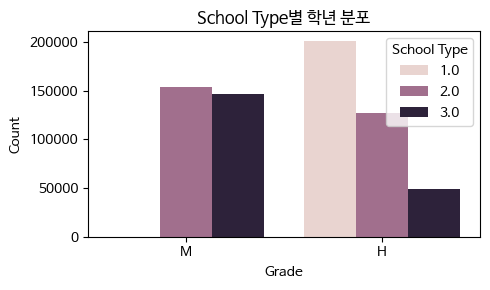

In [158]:
plot_df = final_df[
    (final_df['grade'] != '소계') & 
    (final_df['school_type'] != '총계')
]

plt.figure(figsize=(5,3))
sns.barplot(data=plot_df, x='school_type', y='count', hue='grade', order=['M', 'H'])

plt.title('School Type별 학년 분포')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.legend(title='School Type')
plt.tight_layout()
plt.show()

In [26]:
# 중학교, 고등학교 등록된 학교 수
user_df.groupby('school_type')['school_id'].nunique()

school_type
H    2457
M    3093
Name: school_id, dtype: int64

In [25]:
# 등록된 학교 수
user_df['school_id'].nunique()

5551

In [29]:
user_df['year'] = user_df['created_at'].dt.year
user_df['month'] = user_df['created_at'].dt.month
user_df['year_month'] = user_df['year'].astype('str') + '_' + user_df['month'].astype('str')

In [30]:
user_df['year_month'].value_counts().reset_index()

,year_month,count
0,2023_5,635505
1,2023_4,19060
2,2023_6,16737
3,2023_7,1849
4,2023_11,731
5,2023_9,605
6,2023_8,524
7,2024_1,455
8,2024_3,446
9,2023_10,409


### 1-2) 회원 포인트 보유현황

(이상치 제거) point 4857.5 미만의 값만 추출

In [ ]:
# point 상한값 설정
q1 = user_df['point'].quantile(0.25)
q3 = user_df['point'].quantile(0.75)

iqr = q3 - q1 

print(q3 + 1.5*iqr)

4857.5


In [203]:
user_simple_table = mem_con.execute("""
                            SELECT user_id,	is_superuser,	is_staff,	gender,	point, grade, school_type
                            FROM user_df
                            WHERE point < 4857.5
                            """).df()
user_simple_table.head()

,user_id,is_superuser,is_staff,gender,point,grade,school_type
0,831956,1,1,None,600,NaN,None
1,831962,0,0,F,2248,2.0,None
2,832151,0,0,M,1519,1.0,None
3,832340,0,0,F,57,1.0,None
4,832520,0,0,M,1039,2.0,None


In [210]:
print("point 상한선 제한 전 : ", user_df.shape)
print("point 상한선 제한 후 : ", user_simple_table.shape)
print("차이 : ", user_df.shape[0] - user_simple_table.shape[0], "(", round((user_df.shape[0] - user_simple_table.shape[0])/user_df.shape[0]*100,2) ,"%)")

point 상한선 제한 전 :  (677085, 24)
point 상한선 제한 후 :  (634476, 7)
차이 :  42609 ( 6.29 %)


In [212]:
user_simple_table.sort_values(by='point', ascending=False)

,user_id,is_superuser,is_staff,gender,point,grade,school_type
91439,950740,0,0,F,4857,2.0,M
387301,1295984,0,0,F,4857,1.0,H
283411,1173728,0,0,F,4857,2.0,M
290521,1182101,0,0,F,4857,1.0,H
251397,1136516,0,0,F,4857,2.0,M
...,...,...,...,...,...,...,...
93716,953367,0,0,M,0,3.0,M
506649,1437209,0,0,M,0,2.0,H
263751,1150967,0,0,M,0,1.0,H
151391,1020318,0,0,M,0,2.0,M


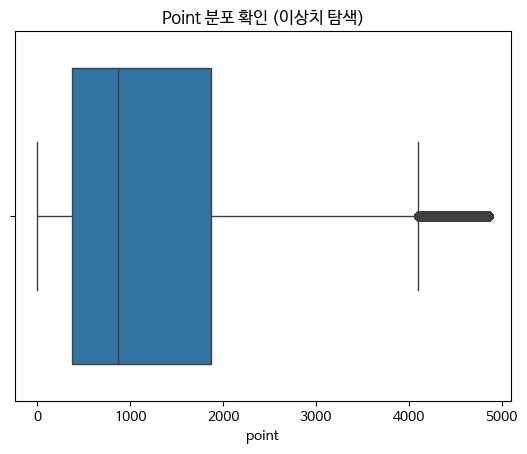

In [213]:
sns.boxplot(x=user_simple_table['point'])
plt.title('Point 분포 확인 (이상치 탐색)')
plt.show()

포인트 구매이력과 비교

In [214]:
positive_point_users = user_simple_table[user_simple_table['point'] > 0]
zero_point_users = user_simple_table[user_simple_table['point'] == 0]
print("포인트가 있는 유저 수:", len(positive_point_users))
print("포인트가 0인 유저 수:", len(zero_point_users))

포인트가 있는 유저 수: 634278
포인트가 0인 유저 수: 198


In [219]:
paymenthistory_df.head()

,id,productId,phone_type,created_at,user_id
0,6,heart.777,A,2023-05-13 21:28:34,1211127
1,7,heart.777,A,2023-05-13 21:29:39,1151343
2,8,heart.777,A,2023-05-13 21:31:33,1002147
3,9,heart.777,A,2023-05-13 21:31:39,1095040
4,11,heart.777,A,2023-05-13 21:34:32,1164081


In [220]:
paymenthistory_df['user_id'].nunique()

59192

학교_학년별 비교

In [281]:
user_df['school_grade'] = user_df['school_type'] + '_' + user_df['grade'].astype('str')

In [284]:
user_school = user_df[['user_id', 'school_grade']]
user_school

,user_id,school_grade
0,831956,NaN
1,831962,NaN
2,832151,NaN
3,832340,NaN
4,832520,NaN
...,...,...
677080,1583729,H_3.0
677081,1583730,M_3.0
677082,1583731,H_3.0
677083,1583732,H_3.0


In [288]:
merged_df = vote_point_df[['user_id', 'question_id', 'delta_point', 'created_at']].merge(user_school, how='left', on='user_id')
merged_df

,user_id,question_id,delta_point,created_at,school_grade
0,849452,209,-300.0,2023-04-28 12:30:48,H_2.0
1,849477,253,-300.0,2023-04-28 12:34:17,H_2.0
2,849566,117,-300.0,2023-04-28 12:41:45,H_2.0
3,849558,110,-300.0,2023-04-28 12:46:14,H_2.0
4,850039,210,-300.0,2023-04-28 13:18:14,H_2.0
...,...,...,...,...,...
1217549,1001607,2614,16.0,2024-05-07 11:29:07,H_1.0
1217550,855525,1679,10.0,2024-05-08 01:34:56,H_1.0
1217551,855525,2605,28.0,2024-05-08 01:35:02,H_1.0
1217552,855525,3801,22.0,2024-05-08 01:36:00,H_1.0


In [296]:
merged_df.groupby('school_grade')['delta_point'].agg(['count', 'mean'])

,count,mean
school_grade,,
H_1.0,442785,6.368983
H_2.0,357309,5.747893
H_3.0,156616,6.165513
M_2.0,157174,9.605628
M_3.0,103670,7.284460


### 1-3) 친구 수 & 출석일 반영 후 상관관계 분석(user_ver2 생성)

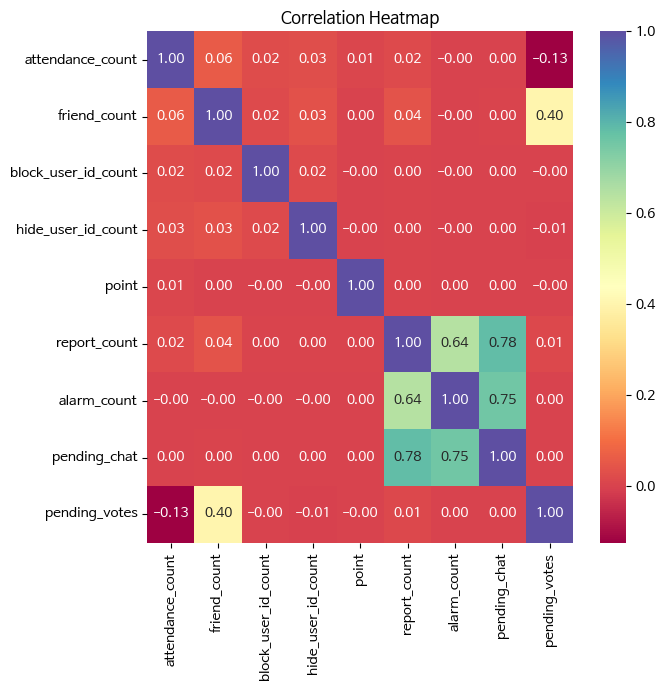

In [72]:
correlation = user_df[['attendance_count', 'friend_count', 'block_user_id_count', 'hide_user_id_count', 'point', 'report_count',	'alarm_count',	'pending_chat',	'pending_votes']].corr()

plt.figure(figsize=(7,7))
sns.heatmap(correlation, annot=True, cmap='Spectral', fmt=".2f", square=False)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [265]:
user_df['ban_status'].value_counts()

ban_status
N     668432
W       7855
NB       608
RB       190
Name: count, dtype: int64

### 2) 투표 참여 유저 비율 확인

In [86]:
user_cnt = user_df['user_id'].nunique()
chosen_user_cnt = vote_point_df['chosen_user_id'].nunique()
vote_user_cnt = vote_point_df['user_id'].nunique()

In [87]:
print("전체 유저수 : ", user_cnt)
print("선택된 유저수 : ", chosen_user_cnt, "(", round(chosen_user_cnt/user_cnt*100,3) , "%)")
print("선택한 유저수 : ", vote_user_cnt, "(", round(vote_user_cnt/user_cnt*100, 3), "%)")

전체 유저수 :  677085
선택된 유저수 :  15426 ( 2.278 %)
선택한 유저수 :  4849 ( 0.716 %)


In [88]:
user_df['user_id'].nunique()

677085

In [95]:
vote_point_df.tail(20)

,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,user_question_record_id,point_owner,delta_points
2229011,161665493,C,2024-05-06 10:57:43,877878,1351,876072,207297875,0,N,2024-05-06 10:57:43,0,0,161665493.0,877878,[9]
2229012,161665495,C,2024-05-06 10:57:58,888131,906,876072,207297877,0,N,2024-05-06 10:57:58,0,0,161665495.0,888131,[10]
2229013,161665496,C,2024-05-06 10:58:03,872759,4681,876072,207297878,0,N,2024-05-06 10:58:03,0,0,161665496.0,872759,[8]
2229014,161665497,C,2024-05-06 10:58:09,875940,694,876072,207297879,0,N,2024-05-06 10:58:09,0,0,161665497.0,875940,[10]
2229015,161665498,C,2024-05-06 10:58:19,876331,3214,876072,207297880,0,N,2024-05-06 10:58:19,0,0,161665498.0,876331,[14]
2229016,161665948,C,2024-05-07 00:13:55,1207066,2482,1208878,208171981,0,N,2024-05-07 00:13:55,0,0,161665948.0,1207066,[8]
2229017,161665949,C,2024-05-07 00:14:02,1212341,3890,1208878,208171982,0,N,2024-05-07 00:14:02,0,0,161665949.0,1212341,[15]
2229018,161665950,C,2024-05-07 00:14:07,1207322,4610,1208878,208171983,0,N,2024-05-07 00:14:07,0,0,161665950.0,1207322,[13]
2229019,161665951,C,2024-05-07 00:14:13,1212293,1109,1208878,208171984,0,N,2024-05-07 00:14:13,0,0,161665951.0,1212293,[5]
2229020,161665952,C,2024-05-07 00:14:20,1323127,4178,1208878,208171985,0,N,2024-05-07 00:14:20,0,0,161665952.0,1323127,[14]


In [90]:
vote_point_df.dtypes

id                                  int64
status                             object
created_at                 datetime64[us]
chosen_user_id                      int64
question_id                         int64
user_id                             int64
question_piece_id                   int64
has_read                            int64
answer_status                      object
answer_updated_at          datetime64[us]
report_count                        int64
opened_times                        int64
user_question_record_id           float64
point_owner                         int64
delta_points                       object
dtype: object

In [163]:
chosen_set = set(vote_point_df['chosen_user_id'].dropna().astype(int))
user_set = set(vote_point_df['user_id'].dropna().astype(int))

In [164]:
# 2. 겹치는 사람 수
intersection_count = len(chosen_set & user_set)
print("겹치는 유저수 : ", intersection_count)

# 3. 안 겹치는 사람 수
# - chosen_user_id에만 있는 사람 수
only_chosen = len(chosen_set - user_set)
print("선택되기만 한 유저수 : ", only_chosen)

# - user_id에만 있는 사람 수
only_user = len(user_set - chosen_set)
print("선택하기만 한 유저수 : ", only_user)

겹치는 유저수 :  4823
선택되기만 한 유저수 :  10603
선택하기만 한 유저수 :  26


### 3) 포인트 사용내역 확인

In [299]:
pointhistory_df.head()

,id,delta_point,created_at,user_id,user_question_record_id
0,790629,9,2023-04-28 12:27:49,849436,771777.0
1,790652,9,2023-04-28 12:28:02,849436,771800.0
2,790664,5,2023-04-28 12:28:09,849436,771812.0
3,790680,13,2023-04-28 12:28:16,849436,771828.0
4,790703,5,2023-04-28 12:28:26,849436,771851.0


In [305]:
pointhistory_df.query('delta_point<0')

,id,delta_point,created_at,user_id,user_question_record_id
1030,808783,-300,2023-04-28 14:31:21,849479,773997.0
1036,808861,-300,2023-04-28 14:31:49,849452,788254.0
1110,810295,-300,2023-04-28 14:41:47,849762,787307.0
1241,812641,-300,2023-04-28 14:55:08,849670,782368.0
1443,815628,-300,2023-04-28 15:15:43,849439,790323.0
...,...,...,...,...,...
2338838,340661110,-500,2024-04-30 10:33:03,1209776,70382111.0
2338839,340661111,-1000,2024-04-30 10:33:13,1209776,70382111.0
2338870,340668595,-200,2024-05-05 14:06:53,1251933,89164250.0
2338906,340671283,-500,2024-05-07 02:26:58,851491,3774736.0


/home/sprintda07/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


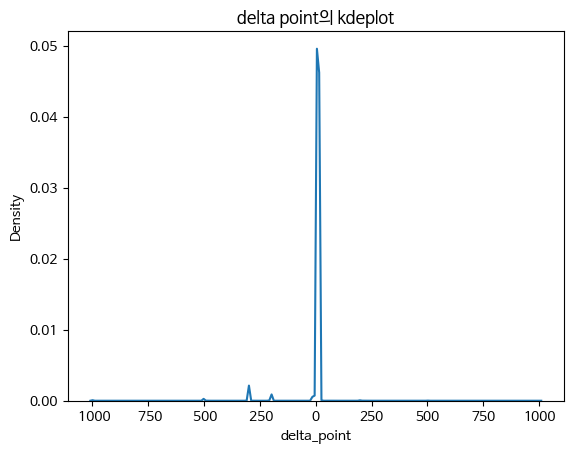

In [300]:
sns.kdeplot(pointhistory_df['delta_point'])
plt.title('delta point의 kdeplot')
plt.show()

/home/sprintda07/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


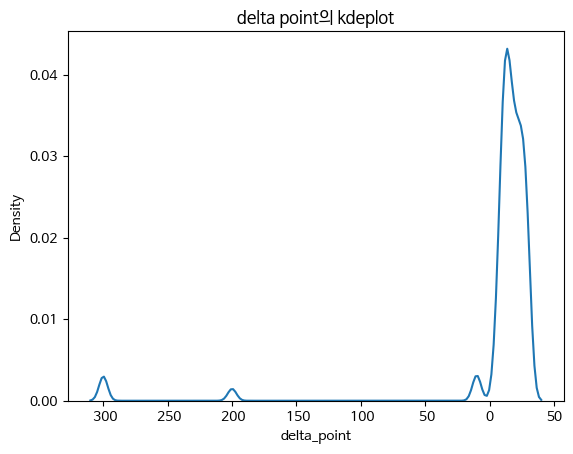

In [165]:
sns.kdeplot(vote_point_df['delta_point'])
plt.title('delta point의 kdeplot')
plt.show()

In [166]:
vote_point_df[vote_point_df['delta_point'] >= 0]

,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,created_at_point,user_question_record_id,id_point,delta_point,user_id_point,time_diff
1486,2146629,C,2023-05-02 11:41:13,849436,183,850574,2645618,0,N,2023-05-02 11:41:13,0,0,2023-05-02 11:41:14,2146629.0,2210454.0,12.0,849436.0,1.0
1492,2153347,C,2023-05-02 11:53:22,850556,444,850031,2748024,0,N,2023-05-02 11:53:22,0,0,2023-05-02 11:53:23,2153347.0,2223180.0,5.0,850556.0,1.0
1500,2157014,C,2023-05-02 11:59:25,849504,288,850215,2715175,0,N,2023-05-02 11:59:25,0,0,2023-05-02 11:59:26,2157014.0,2230658.0,14.0,849504.0,1.0
1501,2157095,C,2023-05-02 11:59:34,850633,453,850215,2715177,1,N,2023-05-02 11:59:34,0,0,2023-05-02 11:59:35,2157095.0,2230824.0,11.0,850633.0,1.0
1504,2161745,C,2023-05-02 12:07:16,855180,295,849692,2746913,0,N,2023-05-02 12:07:16,0,0,2023-05-02 12:07:17,2161745.0,2240307.0,11.0,855180.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217549,161666166,C,2024-05-07 11:29:07,945560,2614,1001607,190864020,1,N,2024-05-07 11:29:07,0,0,2024-05-07 11:29:07,161666166.0,340671667.0,16.0,NaN,0.0
1217550,161666461,C,2024-05-08 01:34:56,850774,1679,855525,200139931,0,N,2024-05-08 01:34:56,0,0,2024-05-08 01:34:56,161666461.0,340672368.0,10.0,NaN,0.0
1217551,161666462,C,2024-05-08 01:35:02,855509,2605,855525,200139932,0,N,2024-05-08 01:35:02,0,0,2024-05-08 01:35:02,161666462.0,340672370.0,28.0,NaN,0.0
1217552,161666463,C,2024-05-08 01:36:00,855526,3801,855525,200139933,0,N,2024-05-08 01:36:00,0,0,2024-05-08 01:36:00,161666463.0,340672372.0,22.0,NaN,0.0


In [222]:
vote_point_df.groupby('status')['delta_point'].agg(['count', 'mean'])

,count,mean
status,,
B,658,-18.481763
C,1156318,17.377249
I,60578,-197.712833


In [223]:
vote_point_df.groupby('has_read')['delta_point'].agg(['count', 'mean'])

,count,mean
has_read,,
0,541626,16.067709
1,675928,-0.885112


In [224]:
vote_point_df.groupby('answer_status')['delta_point'].agg(['count', 'mean'])

,count,mean
answer_status,,
A,111761,-8.542112
N,1097928,8.446031
P,7865,-27.214495


In [225]:
vote_point_df.groupby('opened_times')['delta_point'].agg(['count', 'mean'])

,count,mean
opened_times,,
0,1156892,17.375824
1,46882,-201.637110
2,11120,-187.286061
3,2660,-173.595113


In [243]:
vote_point_df.groupby(['opened_times','has_read'])['delta_point'].agg(['count', 'mean'])

count        mean
opened_times has_read                    
0            0         537994   17.828173
             1         618898   16.982608
1            0           3632 -244.702919
             1          43250 -198.020578
2            1          11120 -187.286061
3            1           2660 -173.595113

In [228]:
vote_simple_table = mem_con.execute("""
                            SELECT user_id,	STRFTIME(created_at, '%Y_%m') AS year_month, question_id,	chosen_user_id,	delta_point, has_read, answer_status, report_count, opened_times,
                            FROM vote_point_df
                            """).df()
vote_simple_table.head()

,user_id,year_month,question_id,chosen_user_id,delta_point,has_read,answer_status,report_count,opened_times
0,849452,2023_04,209,849489,-300.0,0,N,0,1
1,849477,2023_04,253,849436,-300.0,0,N,0,1
2,849566,2023_04,117,849479,-300.0,0,N,0,1
3,849558,2023_04,110,849503,-300.0,1,N,0,1
4,850039,2023_04,210,849983,-300.0,0,N,0,1


In [231]:
vote_date = vote_simple_table['year_month'].value_counts().reset_index()
vote_date

,year_month,count
0,2023_05,1104677
1,2023_06,71341
2,2023_04,30798
3,2023_07,5396
4,2023_08,2050
5,2023_09,1665
6,2023_12,502
7,2023_10,330
8,2023_11,253
9,2024_01,236


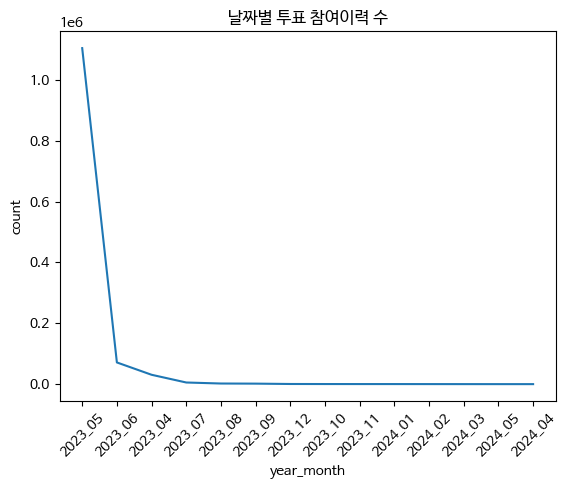

In [266]:
sns.lineplot(data= vote_date, x='year_month', y='count')
plt.xticks(rotation=45)
plt.title("날짜별 투표 참여이력 수")
plt.show()

### 4) 질문내용 확인

In [237]:
vote_question_table = mem_con.execute("""
    SELECT 
        v.user_id,
        STRFTIME(v.created_at, '%Y_%m') AS year_month,
        v.question_id,
        q.question_text,
        v.chosen_user_id,
        v.delta_point,
        v.has_read,
        v.answer_status,
        v.report_count,
        v.opened_times
    FROM vote_point_df AS v
    LEFT JOIN polls_question_df AS q
    ON v.question_id = q.id
""").df()

In [238]:
vote_question_table.head()

,user_id,year_month,question_id,question_text,chosen_user_id,delta_point,has_read,answer_status,report_count,opened_times
0,849452,2023_04,209,항상 좋은 냄새가 나는 사람은?,849489,-300.0,0,N,0,1
1,849477,2023_04,253,생각이 가장 깊은 사람은?,849436,-300.0,0,N,0,1
2,849566,2023_04,117,조용한 매력이 있는 친구,849479,-300.0,0,N,0,1
3,849558,2023_04,110,내가 성별이 바뀐다면 만나고 싶은 사람은?,849503,-300.0,1,N,0,1
4,850039,2023_04,210,친구들에게 가장 인정받는 사람은?,849983,-300.0,0,N,0,1


In [239]:
vote_question_table['question_text'].nunique()

3902

In [270]:
print("상위 10개 질문", vote_question_table['question_text'].value_counts().head(10))
print('-------------------------')
print("하위 10개 질문", vote_question_table['question_text'].value_counts().tail(10))

상위 10개 질문 question_text
vote                             9695
2세가 가장 귀여울 것 같은 사람은?             2171
같이 캠핑가고 싶은 사람은?                  2122
라면 잘 끓일 것 같은 사람은?                2114
처음 보는 사람과 가장 빨리 친해질 것 같은 사람은?    1996
모든 사람과 잘 지낼 것 같은 사람은?            1986
축제에서 공연을 제일 잘 할거 같은 사람은?         1984
앞으로의 인생을 가장 재미있게 살것 같은 사람은?      1974
반려동물과 가장 잘 지낼거 같은 사람은?           1956
가장 깔끔할 것 같은 친구는?                 1956
Name: count, dtype: int64
-------------------------
하위 10개 질문 question_text
MBTI 제일 반전이였던 친구는?                      5
내가 가장 아끼는 친구                            4
한번쯤 목마를 태워주고 싶은사람은?                     4
가장 냉정한 사람                               4
여기서 연락 기다리고 있는 사람은?                     4
떨어져 있어도 같이 있는 것 같은 사람은?                 4
만약에 영혼이 바뀐다면 누가 되고싶어?                   4
사달라는거 다 사줄 것 같은 사람은?                    1
개학 하자마자 인사 될것 같은 사람                     1
할머니,  할아버지가 돼도 이 친구만큼은 연락하고 지낼 것 같아!    1
Name: count, dtype: int64


### 5) 이벤트 테이블

In [271]:
event_info_df.head()

,id_log,created_at_log,event_id,user_id,plus_point_log,id_event,title,plus_point_event,event_type,is_expired,created_at_event
0,2,2023-06-22 09:25:16,1,1193618,500,1,코드잇 은행 가입 이벤트,500,FCFS,1,2023-06-20 11:56:38
1,3,2023-06-22 09:38:53,1,928351,500,1,코드잇 은행 가입 이벤트,500,FCFS,1,2023-06-20 11:56:38
2,4,2023-06-22 10:32:15,1,904872,500,1,코드잇 은행 가입 이벤트,500,FCFS,1,2023-06-20 11:56:38
3,5,2023-06-22 13:03:06,1,974697,500,1,코드잇 은행 가입 이벤트,500,FCFS,1,2023-06-20 11:56:38
4,6,2023-06-22 13:40:38,1,1168260,500,1,코드잇 은행 가입 이벤트,500,FCFS,1,2023-06-20 11:56:38


In [274]:
event_info_df['user_id'].nunique()

308

### 6) point 분석

In [12]:
vote_point_df_ver2.head()

,created_at_x,id,status,chosen_user_id,question_id,user_id_x,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,delta_point,created_at_y,point_user
0,2023-04-28 12:27:49,771777.0,C,849469.0,252.0,849436.0,998458.0,0.0,N,2023-04-28 12:27:49,0.0,0.0,9.0,2023-04-28 12:27:49,chooser
1,2023-04-28 12:28:02,771800.0,C,849446.0,244.0,849436.0,998459.0,0.0,N,2023-04-28 12:28:02,0.0,0.0,9.0,2023-04-28 12:28:02,chooser
2,2023-04-28 12:28:09,771812.0,C,849454.0,183.0,849436.0,998460.0,1.0,N,2023-04-28 12:28:09,0.0,0.0,5.0,2023-04-28 12:28:09,chooser
3,2023-04-28 12:28:16,771828.0,C,847375.0,101.0,849436.0,998461.0,0.0,N,2023-04-28 12:28:16,0.0,0.0,13.0,2023-04-28 12:28:16,chooser
4,2023-04-28 12:28:26,771851.0,C,849477.0,209.0,849436.0,998462.0,1.0,N,2023-04-28 12:28:26,0.0,0.0,5.0,2023-04-28 12:28:26,chooser


In [13]:
vote_point_df_ver2.shape

(2335930, 15)

In [28]:
print("선택된 유저수 : ", vote_point_df_ver2['chosen_user_id'].nunique())
print("선택한 유저수 : ", vote_point_df_ver2['user_id_x'].nunique())

선택된 유저수 :  15426
선택한 유저수 :  4849


In [31]:
vote_point_df_ver2.isna().sum()

created_at_x         0
id                   0
status               0
chosen_user_id       0
question_id          0
user_id_x            0
question_piece_id    0
has_read             0
answer_status        0
answer_updated_at    0
report_count         0
opened_times         0
delta_point          4
created_at_y         4
point_user           4
dtype: int64

In [33]:
vote_point_df_ver2[vote_point_df_ver2['delta_point'].isna()]

,created_at_x,id,status,chosen_user_id,question_id,user_id_x,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,delta_point,created_at_y,point_user
2026045,2023-05-27 14:24:03,120980026.0,C,887050.0,1226.0,886111.0,148140791.0,0.0,N,2023-05-27 14:24:03,0.0,0.0,NaN,NaT,None
2026050,2023-05-27 14:24:12,120980190.0,C,1119693.0,346.0,1001610.0,153417374.0,1.0,N,2023-05-27 14:24:12,0.0,0.0,NaN,NaT,None
2027249,2023-05-27 14:52:09,121108950.0,C,1498168.0,534.0,1404671.0,153759320.0,1.0,N,2023-05-27 14:52:09,0.0,0.0,NaN,NaT,None
2027252,2023-05-27 14:52:09,121109094.0,C,1065317.0,372.0,917557.0,154481645.0,1.0,N,2023-05-27 14:52:09,0.0,0.0,NaN,NaT,None


테이블 나누기

In [15]:
chooser_df = vote_point_df_ver2.loc[vote_point_df_ver2['point_user'] == 'chooser']
chooser_df.head()

,created_at_x,id,status,chosen_user_id,question_id,user_id_x,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,delta_point,created_at_y,point_user
0,2023-04-28 12:27:49,771777.0,C,849469.0,252.0,849436.0,998458.0,0.0,N,2023-04-28 12:27:49,0.0,0.0,9.0,2023-04-28 12:27:49,chooser
1,2023-04-28 12:28:02,771800.0,C,849446.0,244.0,849436.0,998459.0,0.0,N,2023-04-28 12:28:02,0.0,0.0,9.0,2023-04-28 12:28:02,chooser
2,2023-04-28 12:28:09,771812.0,C,849454.0,183.0,849436.0,998460.0,1.0,N,2023-04-28 12:28:09,0.0,0.0,5.0,2023-04-28 12:28:09,chooser
3,2023-04-28 12:28:16,771828.0,C,847375.0,101.0,849436.0,998461.0,0.0,N,2023-04-28 12:28:16,0.0,0.0,13.0,2023-04-28 12:28:16,chooser
4,2023-04-28 12:28:26,771851.0,C,849477.0,209.0,849436.0,998462.0,1.0,N,2023-04-28 12:28:26,0.0,0.0,5.0,2023-04-28 12:28:26,chooser


In [25]:
chooser_df['user_id_x'].nunique()

4849

In [39]:
print(chooser_df['delta_point'].mean())
print(chooser_df['delta_point'].min())

9.982581859684105
-1000.0


In [40]:
chooser_df['delta_point'].nunique()

15

In [41]:
chooser_df['delta_point'].unique()

array([    9.,     5.,    13.,    10.,    12.,    15.,    14.,     8.,
           6.,    11.,     7.,   -10.,  -200.,  -500., -1000.])

In [16]:
chosen_df = vote_point_df_ver2.loc[vote_point_df_ver2['point_user'] == 'chosen']
chosen_df.head()

,created_at_x,id,status,chosen_user_id,question_id,user_id_x,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,delta_point,created_at_y,point_user
11,2023-04-28 12:29:13,771940.0,I,849634.0,297.0,849436.0,998465.0,1.0,N,2023-04-28 12:29:13,0.0,1.0,-300.0,2023-05-07 04:40:33,chosen
36,2023-04-28 12:30:48,772123.0,I,849489.0,209.0,849452.0,999059.0,0.0,N,2023-04-28 12:30:48,0.0,1.0,-300.0,2023-04-28 17:28:06,chosen
38,2023-04-28 12:30:49,772126.0,I,849488.0,257.0,849438.0,998594.0,1.0,N,2023-04-28 12:30:49,0.0,2.0,-300.0,2023-05-07 17:15:28,chosen
39,2023-04-28 12:30:49,772126.0,I,849488.0,257.0,849438.0,998594.0,1.0,N,2023-04-28 12:30:49,0.0,2.0,-500.0,2023-06-04 06:34:27,chosen
100,2023-04-28 12:33:33,772488.0,I,849446.0,245.0,849445.0,999492.0,0.0,N,2023-04-28 12:33:33,0.0,1.0,-300.0,2023-05-01 09:00:56,chosen


In [26]:
chosen_df['chosen_user_id'].nunique()

5007

In [42]:
chosen_df['delta_point'].nunique()

16

In [43]:
chosen_df['delta_point'].unique()

array([ -300.,  -500.,  -200.,   -10., -1000.,     8.,    13.,    12.,
           9.,     6.,    11.,    10.,    15.,     5.,     7.,    14.])

### 7) 탈퇴기록

In [45]:
userwithdraw_df.head()

,id,reason,created_at
0,42,재밌는 질문이 없어서,2023-03-29 13:22:12
1,43,함께 할 친구가 없어서,2023-03-29 13:24:59
2,44,함께 할 친구가 없어서,2023-03-29 13:53:32
3,45,함께 할 친구가 없어서,2023-03-29 13:54:03
4,46,재밌는 질문이 없어서,2023-03-30 00:31:19


In [48]:
userwithdraw_df.shape

(70764, 3)

In [22]:
userwithdraw_df['year'] = userwithdraw_df['created_at'].dt.year
userwithdraw_df['month'] = userwithdraw_df['created_at'].dt.month
userwithdraw_df['year_month'] = userwithdraw_df['year'].astype('str') + '_' + userwithdraw_df['month'].astype('str')

In [24]:
userwithdraw_df['year_month'].value_counts().reset_index()

,year_month,count
0,2023_5,44845
1,2023_6,9642
2,2023_7,4811
3,2023_9,2450
4,2023_4,2397
5,2023_8,2310
6,2023_10,1164
7,2023_11,837
8,2024_1,697
9,2023_12,693


In [46]:
userwithdraw_df['reason'].unique()

array(['재밌는 질문이 없어서', '함께 할 친구가 없어서', '기타 이유', 'test', '버그가 너무 많아서',
       '구독료가 너무 비싸서', '기타', 'admin'], dtype=object)

In [55]:
reason_df = userwithdraw_df['reason'].value_counts().reset_index()
reason_df['percentage'] = round((reason_df['count']/userwithdraw_df.shape[0])*100, 3)
reason_df

,reason,count,percentage
0,기타 이유,40301,56.951
1,함께 할 친구가 없어서,14450,20.420
2,재밌는 질문이 없어서,13133,18.559
3,버그가 너무 많아서,2031,2.870
4,구독료가 너무 비싸서,730,1.032
5,admin,61,0.086
6,test,53,0.075
7,기타,5,0.007


# 4. 분류모델 돌려보기

In [12]:
final_user_df = mem_con.execute("""
                FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/final_user_df.parquet')
                """).df()

In [13]:
final_user_df.head()

,created_at,user_id,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt
0,2023-03-31 09:05:51.903699,833024,F,393,0,N,0,0,41,0,0,0,0,0,경기도 군포시,158.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2023-03-31 14:32:36.425315,833041,F,885000006,1,N,1,8,67,0,0,53,0,0,충청남도 천안시 동남구,131.0,H_3,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
2,2023-03-31 15:55:48.870381,833112,M,290,1,N,0,1,13,0,0,3,0,0,충청남도 천안시 서북구,347.0,H_3,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
3,2023-03-31 15:56:52.300066,833113,M,2801,1,N,0,3,23,0,0,0,0,49,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0
4,2023-03-31 15:57:39.008717,833154,F,5883,1,N,0,1,126,0,0,1,0,17,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
final_user_df['year'] = final_user_df['created_at'].dt.year
final_user_df['month'] = final_user_df['created_at'].dt.month
final_user_df['year_month'] = final_user_df['year'].astype('str') + '_' + final_user_df['month'].astype('str')

In [32]:
print(final_user_df.shape)
print(final_user_df['user_id'].nunique())

(676987, 28)
676987


In [33]:
final_user_df.describe()

,created_at,user_id,point,is_push_on,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,student_count,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt,year,month
count,676987,6.769870e+05,6.769870e+05,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000,676987.000000
mean,2023-05-15 22:44:04.528038,1.212977e+06,3.023262e+03,0.843114,0.036234,0.850770,53.332139,0.028554,0.764772,3.282397,0.073152,84.639591,206.806301,0.160392,3.294502,1.798495,1.798495,0.000451,0.140508,0.000241,0.000307,2023.002069,5.014260
min,2023-03-31 09:05:51.903699,8.330240e+05,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023.000000,1.000000
25%,2023-05-09 01:39:12.498951,1.028102e+06,4.000000e+02,1.000000,0.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,2.000000,136.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023.000000,5.000000
50%,2023-05-13 10:51:03.883902,1.211735e+06,9.650000e+02,1.000000,0.000000,1.000000,49.000000,0.000000,0.000000,0.000000,0.000000,29.000000,199.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023.000000,5.000000
75%,2023-05-20 07:48:35.328402,1.397892e+06,2.183000e+03,1.000000,0.000000,1.000000,70.000000,0.000000,0.000000,4.000000,0.000000,122.000000,272.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023.000000,5.000000
max,2024-05-09 08:31:17.710824,1.583733e+06,8.850000e+08,1.000000,60.000000,238.000000,1373.000000,178.000000,3557.000000,310.000000,256.000000,3352.000000,578.000000,343.000000,2955.000000,2786.000000,1239.000000,1.000000,60.000000,2.000000,19.000000,2024.000000,12.000000
std,NaN,2.138736e+05,1.076029e+06,0.363694,0.363340,0.845339,32.226012,0.447570,13.936428,7.307527,0.645079,123.267547,97.384453,3.088220,47.261824,28.704927,23.071207,0.021221,0.647235,0.015798,0.036983,0.045444,0.415218


In [ ]:
# 숫자형 컬럼만 선택
numeric_cols = final_user_df.select_dtypes(include=['number']).columns
exclude_cols = ['user_id', 'is_push_on']
f_numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
f_numeric_cols

['point',
 'report_count',
 'alarm_count',
 'friend_count',
 'block_user_id_count',
 'hide_user_id_count',
 'attendance_count',
 'pending_chat',
 'pending_votes',
 'student_count',
 'pointuse_cnt',
 'pointget_cnt',
 'vote_cnt',
 'chosen_cnt',
 'event_cnt',
 'buy_cnt',
 'buyfail_cnt',
 'friendreport_cnt',
 'year',
 'month']

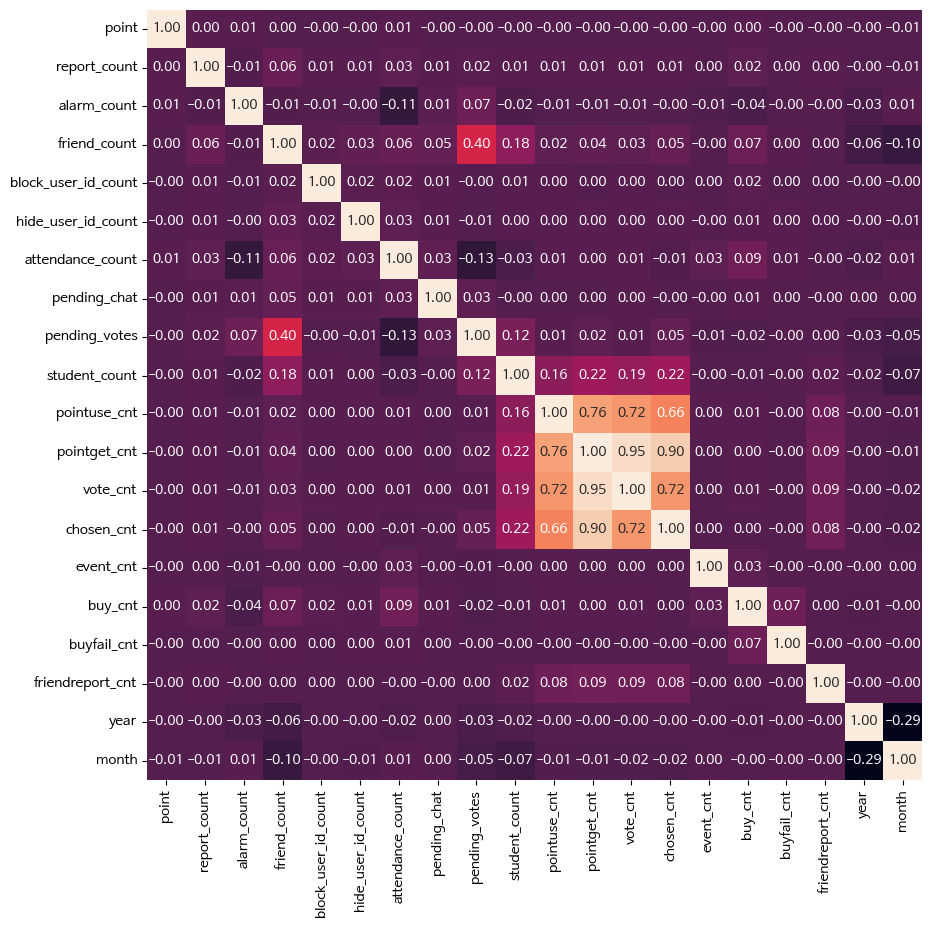

In [37]:
corr = final_user_df[f_numeric_cols].corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cbar=False, fmt=".2f")
plt.show()